# *Utils

In [177]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [178]:
import os
import re
import cv2
import math
import pickle
import random
import time
import warnings
import functools
from collections import defaultdict, deque
from datetime import datetime

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import seaborn as sns
from scipy.io import loadmat
from scipy.sparse import csr_matrix
from scipy.stats import norm, expon, lognorm, vonmises
from tqdm import tqdm

In [179]:
def timer(func):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"[DEBUG] Time taken by func \"{func.__name__}\" : {round(end - start, 6)} seconds")
        return result
    return wrapper

In [180]:
%cd /content/drive/MyDrive/vis

/content/drive/.shortcut-targets-by-id/1x0X9JLucQlOjpwr70P2e3BcR7ouEShX9/vis


In [181]:
# !sudo apt-get install tree
%pip install networkit
%pip install rich

from rich.console import Console

In [182]:
# # !clear
# !tree 20kX\ Yaxing
# !tree Results\ Yaxing

# Load

In [183]:
# def get_largest_component(sparse_matrix):
#     G = nx.Graph(sparse_matrix)
#     largest_cc = max(nx.connected_components(G), key=len)
#     G_largest = G.subgraph(largest_cc).copy()

#     # Use the correct function depending on your version of networkx
#     if hasattr(nx, 'to_scipy_sparse_array'):
#         return nx.to_scipy_sparse_array(G_largest), largest_cc
#     else:
#         return nx.to_scipy_sparse_matrix(G_largest), largest_cc

In [184]:
def find_image_file(set_name, resolution, original_graphs_path):
    directory_path = os.path.join(original_graphs_path, set_name)
    if not os.path.exists(directory_path):
        raise FileNotFoundError(f"Directory not found: {directory_path}")

    pattern = re.compile(rf"\b{re.escape(resolution)}\b")
    if set_name == 'B':   # due to special organization of B
        directory_path = os.path.join(directory_path, "1811")
    for file_name in os.listdir(directory_path):
        if pattern.search(file_name):
            return os.path.join(directory_path, file_name)

    raise FileNotFoundError(f"No image file found for set {set_name} with resolution {resolution} in {directory_path}")

def load_data(set_name, resolution, base_path='/content/drive/MyDrive/vis'):
    positions_path = os.path.join(base_path, 'position')
    sparse_matrices_path = os.path.join(base_path, 'sparse_matrices')
    original_graphs_path = os.path.join(base_path, 'Original Graphs')

    # Construct file names based on resolution and set name
    positions_file = os.path.join(positions_path, f'{set_name}_{resolution}_postion.npy')
    matrix_file = os.path.join(sparse_matrices_path, f'sparse_matrices_{resolution}.npz')
    image_file = find_image_file(set_name, resolution, original_graphs_path)
    print(f'[DEBUG] The position file is {positions_file}, \n\tthe matrix_file is {matrix_file}, \n\tand the image is {image_file}')

    if not os.path.exists(image_file):
        raise FileNotFoundError(f"Image file not found: {image_file}")

    positions = np.load(positions_file, allow_pickle=True)
    matrix_data = np.load(matrix_file, allow_pickle=True)

    if set_name == 'C' or set_name == 'C1':
        if 'C' in matrix_data:
            set_name = 'C'
        elif 'C1' in matrix_data:
            set_name = 'C1'
        else:
            raise KeyError("Neither 'C' nor 'C1' found in sparse_matrix")

    sparse_matrix = matrix_data[set_name].item()
    image = cv2.imread(image_file, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Failed to load image from file: {image_file}")

    return positions, sparse_matrix, image

def normalize(value, min_value, max_value):
    return (value - min_value) / (max_value - min_value)



def plot_network(positions, sparse_matrix, image, set_name, resolution,
                 save=False, base_path='/content/drive/MyDrive/vis/Results Yaxing'):
    positions[:, [0, 1]] = positions[:, [1, 0]]
    min_x, max_x = positions[:, 0].min(), positions[:, 0].max()
    min_y, max_y = positions[:, 1].min(), positions[:, 1].max()

    # Load and resize image
    def resize_image(image, target_size=512):
        h, w = image.shape
        scalefactor = target_size / max(w, h)
        return cv2.resize(image, (int(scalefactor * w), int(scalefactor * h)))

    canvas_image_gray = resize_image(image)
    canvas_height, canvas_width = canvas_image_gray.shape

    # Normalize and scale positions
    scaled_positions = np.zeros_like(positions)
    scaled_positions[:, 0] = normalize(positions[:, 0], min_x, max_x) * canvas_width
    scaled_positions[:, 1] = normalize(positions[:, 1], min_y, max_y) * canvas_height

    # Convert positions to a dictionary for easier access
    position_dict = {i: pos for i, pos in enumerate(scaled_positions)}
    rows, cols = sparse_matrix.nonzero()

    # Plot image and network
    plt.figure(figsize=(10, 10))
    plt.imshow(canvas_image_gray, cmap='gray')

    # Plot edges
    for s, e in zip(rows, cols):
        if s in position_dict and e in position_dict:
            x1, y1 = position_dict[s]
            x2, y2 = position_dict[e]
            plt.plot([x1, x2], [y1, y2], color='lime', linewidth=2)

    # Plot nodes
    plt.plot(scaled_positions[:, 0], scaled_positions[:, 1], 'bo', markersize=4)

    plt.title(f'Original Graph - Set {set_name} Res {resolution}')
    plt.axis('off')
    plt.tight_layout()

    if save:
        folder_path = os.path.join(base_path, f"Set {set_name} Res {resolution}")
        os.makedirs(folder_path, exist_ok=True)
        plt.savefig(os.path.join(folder_path, f'Original Graph - Set {set_name} Res {resolution}.png'))
    else:
        plt.show()

    return rows, cols, position_dict, [int(max_x - min_x), int(max_y - min_y)]

In [185]:
def plot_network(positions, sparse_matrix, image, set_name, resolution,
                 save=False, base_path='/content/drive/MyDrive/vis/Results Yaxing'):
    # Step 1: Find the largest connected component
    G = nx.Graph(sparse_matrix)
    largest_cc = max(nx.connected_components(G), key=len)

    # Step 2: Filter positions and sparse matrix to keep only the largest connected component
    largest_cc = sorted(largest_cc)  # Sort to maintain consistent order
    positions = positions[largest_cc, :]  # Filter positions

    # Filter the sparse matrix by reconstructing it for the largest connected component
    G_largest = G.subgraph(largest_cc).copy()
    rows, cols = np.array(G_largest.edges()).T  # Recreate rows and cols from largest component

    # Normalize and scale positions
    positions[:, [0, 1]] = positions[:, [1, 0]]
    min_x, max_x = positions[:, 0].min(), positions[:, 0].max()
    min_y, max_y = positions[:, 1].min(), positions[:, 1].max()

    def resize_image(image, target_size=512):
        h, w = image.shape
        scalefactor = target_size / max(w, h)
        return cv2.resize(image, (int(scalefactor * w), int(scalefactor * h)))

    canvas_image_gray = resize_image(image)
    canvas_height, canvas_width = canvas_image_gray.shape

    scaled_positions = np.zeros_like(positions)
    scaled_positions[:, 0] = normalize(positions[:, 0], min_x, max_x) * canvas_width
    scaled_positions[:, 1] = normalize(positions[:, 1], min_y, max_y) * canvas_height

    position_dict = {i: pos for i, pos in enumerate(scaled_positions)}

    # Plot image and network
    plt.figure(figsize=(10, 10))
    plt.imshow(canvas_image_gray, cmap='gray')

    # Plot edges
    for s, e in zip(rows, cols):
        if s in position_dict and e in position_dict:
            x1, y1 = position_dict[s]
            x2, y2 = position_dict[e]
            plt.plot([x1, x2], [y1, y2], color='lime', linewidth=2)

    # Plot nodes
    plt.plot(scaled_positions[:, 0], scaled_positions[:, 1], 'bo', markersize=4)

    plt.title(f'Original Graph - Set {set_name} Res {resolution}')
    plt.axis('off')
    plt.tight_layout()

    if save:
        folder_path = os.path.join(base_path, f"Set {set_name} Res {resolution}")
        os.makedirs(folder_path, exist_ok=True)
        plt.savefig(os.path.join(folder_path, f'Original Graph - Set {set_name} Res {resolution}.png'))
    else:
        plt.show()

    return rows, cols, position_dict, [int(max_x - min_x), int(max_y - min_y)]

[DEBUG] The position file is /content/drive/MyDrive/vis/position/D_10kX_postion.npy, 
	the matrix_file is /content/drive/MyDrive/vis/sparse_matrices/sparse_matrices_10kX.npz, 
	and the image is /content/drive/MyDrive/vis/Original Graphs/D/300kV 10kX  Pre-GIF 1753.tif


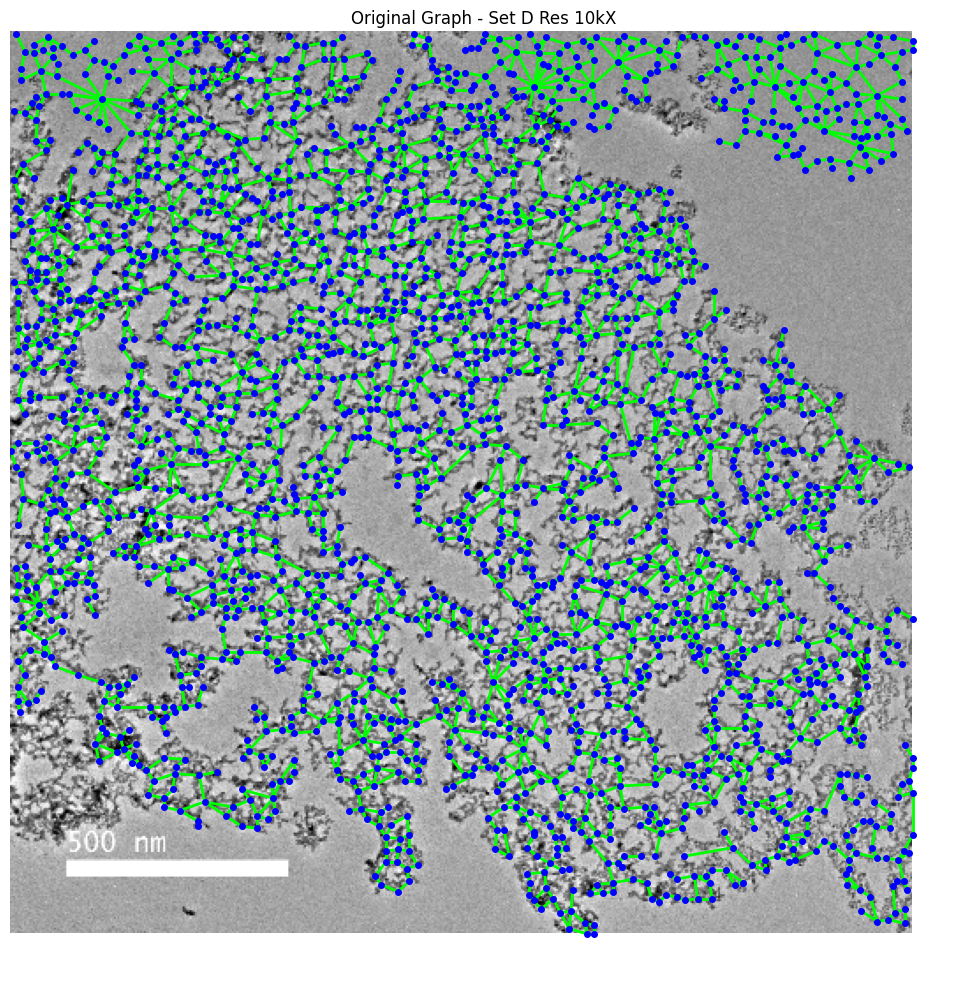

((2392, 2), (2392, 2392), (3431,), (3431,), ())

In [186]:
set_name = 'D'
resolution = '10kX'

positions, sparse_matrix, image = load_data(set_name, resolution)
edges = sparse_matrix
rows, cols, position_dict, _ = plot_network(positions, sparse_matrix, image, set_name, resolution)
np.shape(positions), np.shape(sparse_matrix), np.shape(rows), np.shape(cols), np.shape(position_dict.keys())

# Extract Properties

## Standard Properties of Original Graph

In [187]:
console = Console()
graph_results = {}

In [188]:
def print_graph_metrics(graph_metrics, set_name, resolution, mode=1):
    mode_mapping = {
        1: ("blue", f"In Original Graph {set_name} - {resolution}, the distribution is:"),
        2: ("magenta", f"In Mimicked Graph {set_name} - {resolution}, the distribution is:")
    }

    if mode not in mode_mapping:
        raise ValueError("Invalid mode. Available modes: 1 (Original), 2 (Mimicked).")

    color, header = mode_mapping[mode]
    console.print(header, style=f"bold {color}")

    for k in sorted(graph_metrics["degree_distribution"].keys()):
        ratio = round(graph_metrics["degree_distribution"][k], 3)
        console.print(f"- {k}: {ratio}", style=color)

    console.print(f"Mean number of nodes in Graph {set_name} - {resolution}: {graph_metrics['mean_num_nodes']}", style=color)
    console.print(f"Mean number of edges in Graph {set_name} - {resolution}: {graph_metrics['mean_num_edges']}", style=color)
    console.print(f"Average closeness centrality in Graph {set_name} - {resolution}: {graph_metrics['avg_closeness_centrality']}", style=color)
    console.print(f"Average degree in Graph {set_name} - {resolution}: {graph_metrics['avg_degree']}", style=color)

def compute_graph_metrics(set_name, resolution, base_path='/content/drive/MyDrive/vis'):
    cache_key = f"{set_name}_{resolution}"

    if cache_key not in graph_results or True:
        positions, sparse_matrix, _ = load_data(set_name, resolution, base_path=base_path)

        adj_matrix = np.array(sparse_matrix.toarray())
        G_original = nx.from_numpy_array(adj_matrix)
        G_original = nx.from_scipy_sparse_array(sparse_matrix)

        largest_component = max(nx.connected_components(G_original), key=len)
        G_largest = G_original.subgraph(largest_component).copy()

        degrees_largest = dict(G_largest.degree())
        unique_degrees_largest, counts_largest = np.unique(list(degrees_largest.values()), return_counts=True)
        degree_distribution_largest = dict(zip(unique_degrees_largest, counts_largest / sum(counts_largest)))

        mean_num_nodes_largest = G_largest.number_of_nodes()
        mean_num_edges_largest = G_largest.number_of_edges()
        avg_degree_largest = np.mean(list(degrees_largest.values()))

        closeness_centrality_largest = nx.closeness_centrality(G_largest)
        avg_closeness_centrality_largest = np.mean(list(closeness_centrality_largest.values()))

        graph_results[cache_key] = {
            "degree_distribution": degree_distribution_largest,
            "mean_num_nodes": mean_num_nodes_largest,
            "mean_num_edges": mean_num_edges_largest,
            "avg_closeness_centrality": avg_closeness_centrality_largest,
            "avg_degree": avg_degree_largest
        }

    print_graph_metrics(graph_results[cache_key], set_name, resolution, mode=1)
    return sparse_matrix

def compute_graph_metrics(set_name, resolution, base_path='/content/drive/MyDrive/vis'):
    cache_key = f"{set_name}_{resolution}"
    sparse_matrix = None
    if cache_key not in graph_results or True:
        positions, sparse_matrix, _ = load_data(set_name, resolution, base_path=base_path)

        adj_matrix = np.array(sparse_matrix.toarray())
        G_original = nx.from_numpy_array(adj_matrix)
        G_original = nx.from_scipy_sparse_array(sparse_matrix)

        largest_component = max(nx.connected_components(G_original), key=len)
        G_largest = G_original.subgraph(largest_component).copy()

        degrees_largest = dict(G_largest.degree())
        unique_degrees_largest, counts_largest = np.unique(list(degrees_largest.values()), return_counts=True)
        degree_distribution_largest = dict(zip(unique_degrees_largest, counts_largest / sum(counts_largest)))

        mean_num_nodes_largest = G_largest.number_of_nodes()
        mean_num_edges_largest = G_largest.number_of_edges()
        avg_degree_largest = np.mean(list(degrees_largest.values()))

        closeness_centrality_largest = nx.closeness_centrality(G_largest)
        avg_closeness_centrality_largest = np.mean(list(closeness_centrality_largest.values()))

        graph_results[cache_key] = {
            "degree_distribution": degree_distribution_largest,
            "mean_num_nodes": mean_num_nodes_largest,
            "mean_num_edges": mean_num_edges_largest,
            "avg_closeness_centrality": avg_closeness_centrality_largest,
            "avg_degree": avg_degree_largest
        }

    print_graph_metrics(graph_results[cache_key], set_name, resolution, mode=1)
    return sparse_matrix


def print_cached_metrics(set_name, resolution, mode=1):
    cache_key = f"{set_name}_{resolution}"

    if cache_key in graph_results:
        print_graph_metrics(graph_results[cache_key], set_name, resolution, mode)
    else:
        console.print(f"No cached metrics found for graph {set_name} - {resolution}.", style="bold red")

In [189]:
# compute_graph_metrics('A', '10kX')
# compute_graph_metrics('B', '20kX')
# compute_graph_metrics('C', '30kX')
# compute_graph_metrics('D', '10kX')
sp_mtx = compute_graph_metrics(set_name, resolution)

[DEBUG] The position file is /content/drive/MyDrive/vis/position/D_10kX_postion.npy, 
	the matrix_file is /content/drive/MyDrive/vis/sparse_matrices/sparse_matrices_10kX.npz, 
	and the image is /content/drive/MyDrive/vis/Original Graphs/D/300kV 10kX  Pre-GIF 1753.tif


In Original Graph D - 10kX, the distribution is:

- 1: 0.064

- 2: 0.277

- 3: 0.466

...

- 13: 0.0

Mean number of nodes in Graph D - 10kX: 2392

Mean number of edges in Graph D - 10kX: 3431

Average closeness centrality in Graph D - 10kX: 0.026793003863827672

Average degree in Graph D - 10kX: 2.8687290969899664

In [190]:
np.shape(sp_mtx)

(2392, 2392)

## Propobilities Distribution

In [191]:
def calculate_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

In [192]:
def propobilities_distribution(rows, cols, position_dict):
    # In Degree
    in_degree_count = defaultdict(int)
    for start, end in zip(rows, cols):
        in_degree_count[start] += 1
    in_degree_count = {node: degree for node, degree in in_degree_count.items() if degree > 0}

    # Group nodes by degree
    nodes_by_degree = defaultdict(list)
    for node, degree in in_degree_count.items():
        nodes_by_degree[degree].append(node)

    # Calculate degree probabilities
    total_nodes = len(in_degree_count)
    degree_probabilities = {degree: len(nodes) / total_nodes for degree, nodes in nodes_by_degree.items()}

    # Adjacency Dictionary
    adjacency_dict = defaultdict(set)
    for start, end in zip(rows, cols):
        adjacency_dict[start].add(end)
        adjacency_dict[end].add(start)

    # Mapping from each degree to the degrees of its connected vertices
    degree_neighbors_map = defaultdict(list)
    for node, neighbors in adjacency_dict.items():
        if node not in in_degree_count:
            continue  # Skip nodes not in in_degree_count
        node_degree = in_degree_count[node]
        neighbor_degrees = [in_degree_count[neighbor] for neighbor in neighbors if neighbor in in_degree_count]
        degree_neighbors_map[node_degree].extend(neighbor_degrees)

    # Calculate degree transition probabilities
    degree_transition_probs = {}
    for degree, neighbor_degrees in degree_neighbors_map.items():
        degree_distribution = defaultdict(int)
        for neighbor_degree in neighbor_degrees:
            degree_distribution[neighbor_degree] += 1
        total_neighbors = sum(degree_distribution.values())
        degree_transition_probs[degree] = {k: v / total_neighbors for k, v in degree_distribution.items()}

    # Degree Edge Lengths and Angles Calculation (Existing Code)
    edge_lengths_by_degree = defaultdict(list)
    angles_by_degree = defaultdict(list)

    normalized_positions = {node: np.array(position, dtype=np.float64) for node, position in position_dict.items()}
    total_length_sum, total_length_count = 0, 0

    for node, node_pos in normalized_positions.items():
        if node not in in_degree_count:
            continue

        neighbors = list(adjacency_dict[node])
        lengths = [calculate_distance(node_pos, normalized_positions[n]) for n in neighbors if n in normalized_positions]
        node_degree = in_degree_count[node]
        if node_degree > 0:
            edge_lengths_by_degree[node_degree].extend(lengths)

        total_length_sum += np.sum(lengths)
        total_length_count += len(lengths)

        if len(neighbors) > 1:
            # Convert neighbors to polar coordinates (angle relative to the node)
            polar_coords = [(n, np.arctan2(np.float64(normalized_positions[n][1] - node_pos[1]), np.float64(normalized_positions[n][0] - node_pos[0])))
                            for n in neighbors if n in normalized_positions]

            # Sort neighbors by their polar angle
            polar_coords.sort(key=lambda x: x[1])

            # Calculate angles between adjacent edges
            angles = []
            for i in range(len(polar_coords)):
                angle_diff = (polar_coords[(i + 1) % len(polar_coords)][1] - polar_coords[i][1]) * (180 / np.pi)
                if angle_diff < 0:
                    angle_diff += 360
                angles.append(round(angle_diff, 0))

            if node_degree > 0:
                angles_by_degree[node_degree].extend(angles)

    average_length = total_length_sum / total_length_count if total_length_count > 0 else 0
    return adjacency_dict, in_degree_count, degree_transition_probs, angles_by_degree, edge_lengths_by_degree, average_length, normalized_positions

In [193]:
adjacency_dict, in_degree_count, degree_transition_probs, angles_by_degree, edge_lengths_by_degree, average_length, normalized_positions = propobilities_distribution(rows, cols, position_dict)

In [194]:
def print_dict_keys(d: dict):
    print(d.keys())

print_dict_keys(in_degree_count)
print_dict_keys(degree_transition_probs)
print_dict_keys(angles_by_degree)
print_dict_keys(edge_lengths_by_degree)

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65, 66, 67, 68, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 81, 82, 83, 84, 86, 87, 88, 89, 90, 92, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 160, 161, 163, 164, 166, 167, 171, 172, 173, 174, 175, 176, 177, 178, 179, 182, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 199, 200, 201, 202, 204, 205, 206, 207, 209, 210, 211, 212, 213, 214, 215, 217, 218, 219, 220, 221, 222, 223, 225, 226, 227, 228, 230, 231, 232, 233, 234, 235, 236, 237, 238, 240, 241, 242, 24

In [195]:
print(set_name, resolution)

D 10kX


## Map Length to Weight

In [196]:
def map_length_to_weight(length, length_bins, weight_baskets, y):
    bin_idx = np.digitize(length, length_bins) - 1
    bin_idx = np.clip(bin_idx, 0, len(length_bins) - 2)

    return random.choice(weight_baskets[bin_idx]) if weight_baskets[bin_idx] else np.mean(y)

def mapping(position_dict, edges, in_degree_count, adjacency_dict, plot=False):
    edge_lengths, edge_weights = [], []

    normalized_positions = {node: np.array(position, dtype=np.float64) for node, position in position_dict.items()}

    for node, node_pos in normalized_positions.items():
        if node not in in_degree_count:
            continue

        neighbors = list(adjacency_dict[node])
        for neighbor in neighbors:
            if neighbor in normalized_positions:
                length = calculate_distance(node_pos, normalized_positions[neighbor])
                weight = edges[node, neighbor]
                edge_lengths.append(length)
                edge_weights.append(weight)

    X = np.array(edge_lengths).reshape(-1, 1).flatten()
    y = np.array(edge_weights)

    print(np.max(edge_lengths), np.min(edge_lengths))
    print(np.max(edge_weights), np.min(edge_weights))

    num_bins = 100
    length_bins = np.linspace(X.min(), X.max(), num_bins + 1)
    weight_baskets = defaultdict(list)

    for length, weight in zip(X, y):
        bin_idx = np.digitize(length, length_bins) - 1
        bin_idx = np.clip(bin_idx, 0, num_bins - 1)
        weight_baskets[bin_idx].append(weight)

    mapped_weights = [map_length_to_weight(length, length_bins, weight_baskets, y) for length in X]

    if not plot:
        return mapped_weights, map_length_to_weight, length_bins, weight_baskets, y

    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, c='blue', alpha=0.4, label='Original Data')
    plt.scatter(X, mapped_weights, c='orange', alpha=0.6, label='Mapped Weights')
    plt.title('Edge Length vs Weight with Basket-Based Mapping')
    plt.xlabel('Length')
    plt.ylabel('Weight')
    plt.legend()
    plt.grid(False)
    plt.show()

    return mapped_weights, map_length_to_weight, length_bins, weight_baskets, y

29.068883707497267 2.0
0.5255949010407159 0.0


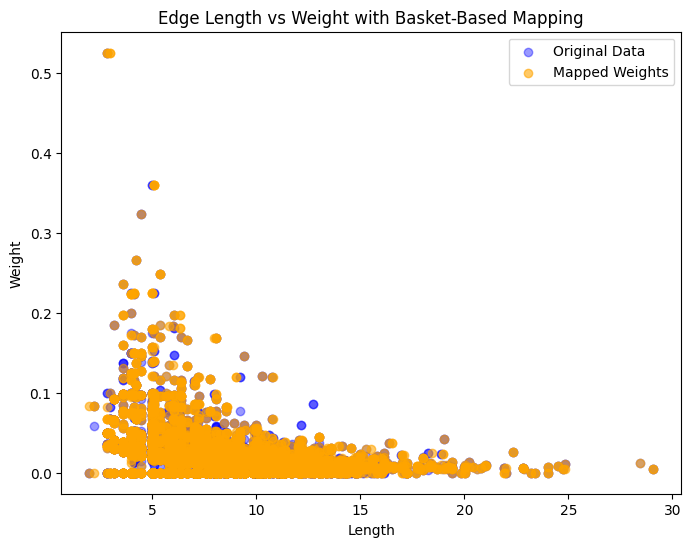

In [197]:
# mapped_weights = mapping(position_dict, edges)
_ = mapping(position_dict, edges, in_degree_count, adjacency_dict, plot=True)

# Design Nodes

In [212]:
class GraphNode:
    degree_distribution = []
    degree_transition_probs = {}
    degree_angles = {}
    degree_edge_lengths = {}
    node_grid = defaultdict(set)
    edge_grid = defaultdict(set)
    grid_size = 8  # The default value is the average value of lengths in the original network
    closed_nodes_factor = 1
    closed_edges_factor = 1
    aborted_edge = 0
    merged_edge = 0
    id_counter = 0

    enable_check_intersection = True
    enable_merge_nodes = True
    enable_clockwise = True
    enable_degree_transition_probs = True
    enable_merge_edges = True


    def __init__(self, position, *, parent=None, parent_angle=None):
        '''
        PRE: param parent and parent_angle must be provided together or not at all.
        POST: The first children of a non-root node is the parent.
        '''
        self.id = GraphNode.id_counter
        GraphNode.id_counter += 1
        self.position = position
        self.clockwise = random.choice([True, False]) if GraphNode.enable_clockwise else True
        self.parent = parent
        self.children = []

        if parent is not None and parent_angle is not None:  # Non-root Node
            self.degree = self.choose_degree_based_on_parent(parent.degree) if GraphNode.enable_degree_transition_probs else random.choice(GraphNode.degree_distribution)
            self.base_angle = (parent_angle + 180) % 360
            self.add_child(self.parent)
        elif parent is None and parent_angle is None:  # Root Node
            self.degree = random.choice(GraphNode.degree_distribution)
            self.base_angle = random.uniform(0, 360)
            self.initialize_root_node()
        else:
            raise ValueError("Both parent and parent_angle must be provided together or not at all.")

    def choose_degree_based_on_parent(self, parent_degree):
        degrees = list(GraphNode.degree_transition_probs[parent_degree].keys())
        probabilities = list(GraphNode.degree_transition_probs[parent_degree].values())
        return np.random.choice(degrees, p=probabilities)

    def initialize_root_node(self):
        length = random.choice(GraphNode.degree_edge_lengths[self.degree])
        child_position = self.polar_to_cartesian([length], [self.base_angle])[0]
        child = GraphNode(child_position, parent=self, parent_angle=self.base_angle)
        edge = (self.position, child_position)
        self.add_child(child)
        self.add_to_grid(self.position)
        self.add_to_grid(child.position)
        self.add_edge_to_grid(edge)

    def add_child(self, child):
        if len(self.children) >= self.degree:
            raise Exception(f"Node {self} cannot have more than {self.degree} children, current children {self.children}")
        self.children.append(child)
        self.add_to_grid(child.position)

    def add_to_grid(self, position):
        key = self.spatial_hash(position)
        GraphNode.node_grid[key].add(self)
        if len(GraphNode.node_grid[key]) > 1000:
            print("Unusual length of nodes collision chain")

    def add_edge_to_grid(self, edge):
        keys = self.edge_spatial_hash(*edge)
        for key in keys:
            GraphNode.edge_grid[key].add(edge)
            if len(GraphNode.edge_grid[key]) > 1000:
                print("Unusual length of edges collision chain")

    def generate_children(self) -> bool:
        if len(self.children) > 1 or self.degree == 1: # Skip visited nodes or Endpoint has no other child
            return False
        angles, lengths = self.generate_angles_and_lengths()
        children_positions = self.polar_to_cartesian(lengths, angles)
        assert len(children_positions) == self.degree - 1

        for child_position, angle in zip(children_positions, angles):
            close_node = self.get_closest_valid_node(child_position)
            if GraphNode.enable_merge_nodes and close_node is not None:
                new_edge = (self.position, close_node.position)
                if not self.check_intersection(new_edge):
                    self.add_child(close_node)
                    self.add_edge_to_grid(new_edge)
                    GraphNode.merged_edge += 1
                else:
                    GraphNode.aborted_edge += 1
            else:
                if GraphNode.enable_merge_edges and self.find_close_edge(child_position):
                    GraphNode.aborted_edge += 1
                    continue
                new_edge = (self.position, child_position)
                if not self.check_intersection(new_edge):
                    child_node = GraphNode(child_position, parent=self, parent_angle=angle)
                    self.add_child(child_node)
                    self.add_edge_to_grid(new_edge)
                    self.add_to_grid(child_node.position)
                else:
                    GraphNode.aborted_edge += 1
        return True

    def get_closest_valid_node(self, position):
        close_nodes_with_distances = self.find_close_node(position)
        if close_nodes_with_distances:
            return min(close_nodes_with_distances, key=lambda x: x[1])[0]
        return None

    def find_close_node(self, position):
        threshold = calculate_distance(self.position, position) * GraphNode.closed_nodes_factor
        key = self.spatial_hash(position)
        neighboring_keys = [
            (key[0] + dx, key[1] + dy)
            for dx in range(-1, 2)
            for dy in range(-1, 2)
        ]
        close_nodes_with_distances = []
        for neighbor_key in neighboring_keys:
            for node in GraphNode.node_grid[neighbor_key]:
                if node != self and node not in self.children:
                    distance = np.linalg.norm(np.array(node.position) - np.array(position))
                    if distance < threshold:
                        close_nodes_with_distances.append((node, distance))
        return close_nodes_with_distances

    def generate_angles_and_lengths(self):
        if self.degree == 1:
            return [], []
        angles = random.choices(GraphNode.degree_angles[self.degree], k=self.degree-1)
        angles = np.cumsum(angles) if self.clockwise else np.cumsum([-angle for angle in angles])
        angles = (angles + self.base_angle).tolist()
        lengths = random.choices(GraphNode.degree_edge_lengths[self.degree], k=self.degree-1)
        return angles, lengths

    def polar_to_cartesian(self, lengths, angles):
        x, y = self.position
        cartesian_coords = []
        for length, angle in zip(lengths, angles):
            angle_rad = np.deg2rad(angle)
            new_x = x + length * np.cos(angle_rad)
            new_y = y + length * np.sin(angle_rad)
            cartesian_coords.append((new_x, new_y))
        return cartesian_coords

    def find_close_edge(self, position):
        key = self.spatial_hash(position)
        neighboring_keys = [
            (key[0] + dx, key[1] + dy)
            for dx in range(-1, 2)
            for dy in range(-1, 2)
        ]
        for neighbor_key in neighboring_keys:
            for edge in GraphNode.edge_grid[neighbor_key]:
                if self.is_non_sibling_edge(edge, position):
                    return True
        return False

    def is_non_sibling_edge(self, edge, position):
        threshold = calculate_distance(self.position, position) * GraphNode.closed_nodes_factor
        if self.parent and (self.parent.position in edge or self.position in edge):
            return False  # Skip edges from the same parent
        p1, p2 = edge
        distances = [
            np.linalg.norm(np.array(position) - np.array(p1)),
            np.linalg.norm(np.array(position) - np.array(p2))
        ]
        return any(distance < threshold for distance in distances)

    def check_intersection(self, new_edge):
        if not GraphNode.enable_check_intersection:
            return False
        keys = self.edge_spatial_hash(*new_edge)
        for key in keys:
            for edge in GraphNode.edge_grid[key]:
                # if new_edge[0] == edge[0] or new_edge[0] == edge[1] or new_edge[1] == edge[0] or new_edge[1] == edge[1]:
                if new_edge[0] in edge or new_edge[1] in edge:
                    continue  # Skip edges with the same endpoint
                if GraphNode.do_intersect(new_edge[0], new_edge[1], edge[0], edge[1]):
                    return True
        return False

    @staticmethod
    def spatial_hash(position, grid_size=None):
        grid_size = grid_size or GraphNode.grid_size
        return (int(position[0] // grid_size), int(position[1] // grid_size))

    @staticmethod
    def edge_spatial_hash(p1, p2, grid_size=None):
        grid_size = grid_size or GraphNode.grid_size
        x_min, x_max = sorted([p1[0], p2[0]])
        y_min, y_max = sorted([p1[1], p2[1]])
        keys = {(int(x // grid_size), int(y // grid_size))
                for x in np.arange(x_min, x_max + grid_size, grid_size)
                for y in np.arange(y_min, y_max + grid_size, grid_size)}
        return keys

    @staticmethod
    def do_intersect(p1, q1, p2, q2):
        def orientation(p, q, r):
            val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
            return 0 if val == 0 else 1 if val > 0 else 2

        def on_segment(p, q, r):
            return min(p[0], r[0]) <= q[0] <= max(p[0], r[0]) and min(p[1], r[1]) <= q[1] <= max(p[1], r[1])

        o1, o2, o3, o4 = orientation(p1, q1, p2), orientation(p1, q1, q2), orientation(p2, q2, p1), orientation(p2, q2, q1)
        return (o1 != o2 and o3 != o4) or (o1 == 0 and on_segment(p1, p2, q1)) or (o2 == 0 and on_segment(p1, q2, q1)) or (o3 == 0 and on_segment(p2, p1, q2)) or (o4 == 0 and on_segment(p2, q1, q2))

    @staticmethod
    def reset(default_grid_size=13):
        GraphNode.node_grid.clear()
        GraphNode.edge_grid.clear()
        GraphNode.aborted_edge = 0
        GraphNode.merged_edge = 0
        GraphNode.grid_size = default_grid_size
        GraphNode.id_counter = 0

    def __repr__(self):
        return f"Node (Id. {self.id})"

    def __str__(self):
        return f"Node (Id. {self.id})"

    # Since we use the coordinates of nodes to deal with hashing, no need to overwrite __eq__ and __hash__
def reset_graph_node(grid_size=13, **kwargs):
    GraphNode.reset(grid_size)
    for attr, value in kwargs.items():
        if hasattr(GraphNode, attr):
            setattr(GraphNode, attr, value)

# Generate Graph

In [216]:
def round_sig(value, digits):
    if value == 0:
        return 0
    else:
        return round(value, digits - len(str(int(abs(value)))))

def generate_nodes_and_edges(frame_boundaries=[[-1000, 1000], [-1000, 1000]], grid_size=13, **kwargs):
    # Reset GraphNode with provided settings
    reset_graph_node(grid_size=grid_size, **kwargs)
    root_node = GraphNode((0, 0))
    node_set, edge_set = {root_node}, set()

    def is_position_within_frame(position, frame):
        x, y = position
        return frame[0][0] <= x <= frame[0][1] and frame[1][0] <= y <= frame[1][1]

    def bfs(root, frame):
        node_queue = deque([root])
        while node_queue:
            if len(node_set) >= 1e5:
                print(f"Excessive node count detected: {len(node_set)}. Aborting...")
                break

            current_node = node_queue.popleft()
            if not is_position_within_frame(current_node.position, frame):
                continue

            if current_node.generate_children():
                print(current_node.degree, current_node.children)
                for child in current_node.children:
                    if child == current_node:
                        continue  # Skip the parent node
                    node_set.add(child)
                    edge_set.add((current_node.position, child.position))
                    node_queue.append(child)  # Warning: Potential infinite loop due to merging

    bfs(root_node, frame_boundaries)
    return node_set, edge_set

def create_adjacency_matrix(nodes, edges):
    node_position_map = {node.position: idx for idx, node in enumerate(nodes)}
    adjacency_matrix = np.zeros((len(nodes), len(nodes)), dtype=int)

    for edge in edges:
        idx1 = node_position_map[edge[0]]
        idx2 = node_position_map[edge[1]]
        adjacency_matrix[idx1, idx2] = adjacency_matrix[idx2, idx1] = 1

    return adjacency_matrix

def plot_and_generate_network(node_set=None, edge_set=None, *, frame_range:int, regenerate_times:int=100, skip_plotting=False, node_only=False, save_plot=False, base_path = '/content/drive/MyDrive/vis/Results Yaxing',  **kwargs):
    if node_set is None and edge_set is None and regenerate_times <= 0:
            warnings.warn("Both node_set and edge_set are None. regenerate_times must be greater than 0. Setting regenerate_times to 100.")
            regenerate_times = 100
    node_set, edge_set = node_set or [], edge_set or []
    frame_boundaries = [[-frame_range, frame_range], [-frame_range, frame_range]]

    GraphNode.degree_distribution = list(in_degree_count.values())
    GraphNode.degree_transition_probs = degree_transition_probs
    GraphNode.degree_angles = angles_by_degree
    GraphNode.degree_edge_lengths = edge_lengths_by_degree

    regen_factor = kwargs.get('regen_factor', 1)
    graph_title = kwargs.get('graph_title', "")
    for _ in range(regenerate_times):
        if len(node_set) > 100:
            print(f"[DEBUG] Nodes generated: {len(node_set)}, edges: {len(edge_set)}.\tAborted edges: {GraphNode.aborted_edge}, merged edges: {GraphNode.merged_edge}")
            break

        all_edge_lengths = [length for lengths in GraphNode.degree_edge_lengths.values() for length in lengths]
        mean_edge_length = np.mean(all_edge_lengths)
        node_set, edge_set = generate_nodes_and_edges(
            frame_boundaries=frame_boundaries,
            grid_size=int(regen_factor * mean_edge_length),
            **kwargs
        )
    else:
        raise Exception(f"Too many attempts to generate graphs. Abort...")

    # print(f"[DEBUG] Grid Size: {int(regen_factor * mean_edge_length)}")
    if node_only:
        return node_set, edge_set, None, None, None

    x_positions = [node.position[0] for node in node_set]
    y_positions = [node.position[1] for node in node_set]

    center_x = sum(x_positions) / len(x_positions)
    center_y = sum(y_positions) / len(y_positions)

    # Determine nodes and edges within the frame
    filtered_nodes = {node for node in node_set
                      if center_x - frame_range / 2 <= node.position[0] <= center_x + frame_range / 2 and
                      center_y - frame_range / 2 <= node.position[1] <= center_y + frame_range / 2}
    filtered_edges = {edge for edge in edge_set
                      if center_x - frame_range / 2 <= edge[0][0] <= center_x + frame_range / 2 and
                      center_y - frame_range / 2 <= edge[0][1] <= center_y + frame_range / 2 and
                      center_x - frame_range / 2 <= edge[1][0] <= center_x + frame_range / 2 and
                      center_y - frame_range / 2 <= edge[1][1] <= center_y + frame_range / 2}
    adjacency_matrix = create_adjacency_matrix(filtered_nodes, filtered_edges)

    if skip_plotting:
        print(f"[DEBUG] Inframe nodes: {len(filtered_nodes)}, edges: {len(filtered_edges)}")
        return node_set, edge_set, filtered_nodes, filtered_edges, adjacency_matrix


    # Plot image and network
    fig, ax = plt.subplots(figsize=(10, 10))

    ax.set_xlim(center_x - frame_range / 2, center_x + frame_range / 2)
    ax.set_ylim(center_y - frame_range / 2, center_y + frame_range / 2)

    for edge in edge_set:
        ax.plot([edge[0][0], edge[1][0]], [edge[0][1], edge[1][1]], 'b-', linewidth=0.5, zorder=2)

    for node in node_set:
        ax.plot(node.position[0], node.position[1], 'ro', markersize=1.5, zorder=2)

    scale_length = 100
    scale_x_start = center_x - frame_range / 2 + 50
    scale_y = center_y - frame_range / 2 + 50

    background_rect = plt.Rectangle((scale_x_start - 5, scale_y - 10), scale_length + 10, 20, facecolor='white', edgecolor='none', zorder=3)
    ax.add_patch(background_rect)
    ax.plot([scale_x_start, scale_x_start + scale_length], [scale_y, scale_y], 'k-', linewidth=2, zorder=3)
    ax.text(scale_x_start + scale_length / 2, scale_y + 5, f'{scale_length}', ha='center', fontsize=12, color='black', zorder=4)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    plt.title('Generated Graph Based on Probability Distributions')
    if save_plot:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f'{graph_title}_graph_{timestamp}.png'
        plt.savefig(base_path + filename, dpi=600)
        print(f"Graph saved as {filename}")
    else:
        plt.show()

    print(f"Nodes after filtering: {len(filtered_nodes)}, edges after filtering: {len(filtered_edges)}")
    return node_set, edge_set, filtered_nodes, filtered_edges, adjacency_matrix

In [217]:
_, _, filtered_nodes, filtered_edges, adj_matrix = plot_and_generate_network(frame_range=1000, skip_plotting=False, regenerate=True, regen_factor=1)

2 [Node (Id. 1), Node (Id. 2)]
2 [Node (Id. 0), Node (Id. 3)]
4 [Node (Id. 1), Node (Id. 2)]
2 [Node (Id. 1), Node (Id. 2)]
2 [Node (Id. 1), Node (Id. 2)]
2 [Node (Id. 1), Node (Id. 2)]
2 [Node (Id. 0), Node (Id. 3)]
2 [Node (Id. 0), Node (Id. 4)]
3 [Node (Id. 1), Node (Id. 5), Node (Id. 6)]
2 [Node (Id. 2), Node (Id. 7)]
2 [Node (Id. 3), Node (Id. 5)]
2 [Node (Id. 1), Node (Id. 2)]
2 [Node (Id. 1)]
2 [Node (Id. 0), Node (Id. 2)]
2 [Node (Id. 1), Node (Id. 3)]
2 [Node (Id. 0), Node (Id. 4)]
2 [Node (Id. 3), Node (Id. 0)]
2 [Node (Id. 1), Node (Id. 2)]
2 [Node (Id. 0), Node (Id. 2)]
3 [Node (Id. 1), Node (Id. 2), Node (Id. 3)]
2 [Node (Id. 0), Node (Id. 4)]
2 [Node (Id. 1), Node (Id. 2)]
3 [Node (Id. 1), Node (Id. 2)]
2 [Node (Id. 0), Node (Id. 3)]
4 [Node (Id. 2), Node (Id. 4), Node (Id. 5), Node (Id. 6)]
2 [Node (Id. 3), Node (Id. 7)]
2 [Node (Id. 3), Node (Id. 8)]
3 [Node (Id. 5), Node (Id. 4), Node (Id. 9)]
2 [Node (Id. 7)]
3 [Node (Id. 1), Node (Id. 2), Node (Id. 3)]
3 [Node (Id. 0

Exception: Too many attempts to generate graphs. Abort...

In [218]:
degree_transition_probs

{2: {3: 0.09818664307828394,
  1: 0.5002211410880142,
  2: 0.37505528527200355,
  4: 0.020344980097302078,
  5: 0.0022114108801415304,
  8: 0.0022114108801415304,
  9: 0.0008845643520566122,
  6: 0.0008845643520566122},
 3: {2: 0.31092436974789917,
  1: 0.5504201680672269,
  3: 0.1092436974789916,
  5: 0.00980392156862745,
  4: 0.011204481792717087,
  6: 0.004201680672268907,
  8: 0.004201680672268907},
 1: {2: 0.4023479188900747,
  3: 0.13980789754535752,
  1: 0.4126645321949484,
  5: 0.008893632159373888,
  4: 0.02703664176449662,
  8: 0.0035574528637495554,
  6: 0.002845962290999644,
  9: 0.002845962290999644},
 5: {1: 0.6578947368421053,
  4: 0.02631578947368421,
  3: 0.18421052631578946,
  2: 0.13157894736842105},
 4: {5: 0.007575757575757576,
  3: 0.06060606060606061,
  8: 0.007575757575757576,
  1: 0.5757575757575758,
  2: 0.3484848484848485},
 8: {3: 0.15, 1: 0.5, 2: 0.25, 4: 0.05, 6: 0.05},
 6: {3: 0.21428571428571427,
  1: 0.5714285714285714,
  2: 0.14285714285714285,
  8: 0.

# Filter the graph

In [22]:
def iteratively_reduce_degree(adj_matrix, target_avg_degree, min_component_size=10):
    G = nx.from_numpy_array(adj_matrix)

    while True:
        # Remove small connected components
        components = [component for component in nx.connected_components(G) if len(component) < min_component_size]
        G.remove_nodes_from(set(node for component in components for node in component))

        degrees = dict(G.degree())
        avg_degree = np.mean(list(degrees.values()))

        if avg_degree <= target_avg_degree:
            break

        # Find the node with the highest degree and remove
        max_degree_node = max(degrees, key=degrees.get)
        G.remove_node(max_degree_node)

        # # Remove nodes with degree 0 (standalone nodes)
        # G.remove_nodes_from([node for node, degree in G.degree() if degree == 0])

    new_adj_matrix = nx.to_numpy_array(G)
    return G, new_adj_matrix

def plot_reduced_graph(G_reduced, val_nodes, title, set_name, resolution, save, base_path='/content/drive/MyDrive/vis/Results Yaxing/'):
    plt.figure(figsize=(10, 10))

    positions = {i: (node.position[0], node.position[1]) for i, node in enumerate(val_nodes)}
    filtered_nodes = list(G_reduced.nodes)
    filtered_edges = list(G_reduced.edges)

    # for s, e in filtered_edges:
    #     if s in positions and e in positions:
    #         x1, y1 = positions[s]
    #         x2, y2 = positions[e]
    #         plt.plot([x1, x2], [y1, y2], 'b-', linewidth=.5, zorder=2)

    # for node in filtered_nodes:
    #     if node in positions:
    #         x, y = positions[node]
    #         plt.plot(x, y, 'ro', markersize=1.5, zorder=2)
    for s, e in filtered_edges:
        pos_s = positions.get(s)
        pos_e = positions.get(e)
        if pos_s and pos_e:
            plt.plot([pos_s[0], pos_e[0]], [pos_s[1], pos_e[1]], 'b-', linewidth=.5, zorder=2)

    for node in filtered_nodes:
        pos = positions.get(node)
        if pos:
            plt.plot(pos[0], pos[1], 'ro', markersize=1.5, zorder=2)

    plt.axis('off')
    # plt.title(title)
    plt.tight_layout()

    if save:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        folder_name = f"Synthetic Graph - Set {set_name} Res {resolution}"
        folder_path = os.path.join(base_path, folder_name)
        os.makedirs(folder_path, exist_ok=True)
        filename = f"Synthetic Graph - Set {set_name} Res {resolution} Time {timestamp}.png"
        filepath = os.path.join(folder_path, filename)
        plt.savefig(filepath)
    else:
        plt.show()

    # Calculate crucial graph metrics
    degrees = list(G_reduced.degree().values())
    unique_degrees, counts = np.unique(degrees, return_counts=True)
    degree_distribution = dict(zip(unique_degrees, counts / sum(counts)))

    mean_num_nodes = G_reduced.number_of_nodes()
    mean_num_edges = G_reduced.number_of_edges()
    avg_degree = np.mean(degrees)
    avg_closeness_centrality = np.mean(list(nx.closeness_centrality(G_reduced).values()))

    return {
        "degree_distribution": degree_distribution,
        "mean_num_nodes": mean_num_nodes,
        "mean_num_edges": mean_num_edges,
        "avg_closeness_centrality": avg_closeness_centrality,
        "avg_degree": avg_degree
    }

In [23]:
# _, _, filtered_nodes, filtered_edges, adj_matrix = plot_and_generate_network(skip_plotting=True, regenerate=True, regen_factor=1)
# G_reduced, adj_reduced = iteratively_reduce_degree(adj_matrix, AVERAGE_DEGREE_ORIGINAL)
# graph_metrics = plot_reduced_graph(G_reduced, filtered_nodes, f'Reduced Graph', save=True)
# print_graph_metrics(graph_metrics, set_name, mode=2)  # mode=2 -> "Mimicked"

In [24]:
# compute_graph_metrics(set_name)

# Control


## func

In [ ]:
import shutil
import pickle
import math
import networkit as nk

from collections import Counter
from scipy import stats
from tqdm import tqdm

In [ ]:
def calculate_edge_lengths(nodes, edges):
    return [calculate_distance(nodes[u], nodes[v]) for u, v in edges]

def assign_weights_to_edges(node_dimension, edges, map_length_to_weight, length_bins, weight_baskets, y):
    edge_lengths = calculate_edge_lengths(node_dimension, edges)
    weights = [map_length_to_weight(length, length_bins, weight_baskets, y) for length in edge_lengths]

    G_weighted = nx.Graph()
    for (u, v), weight in zip(edges, weights):
        G_weighted.add_edge(u, v, weight=weight)

    return G_weighted

def reindex_graph_nodes(G):
    mapping = {node: idx for idx, node in enumerate(G.nodes())}
    return nx.relabel_nodes(G, mapping), mapping

def plot_reduced_graph_with_positions(G, node_positions, title, save=False, base_path='/content/drive/MyDrive/vis/Results Yaxing/'):
    plt.figure(figsize=(10, 10))

    for s, e in G.edges:
        x1, y1 = node_positions[s]
        x2, y2 = node_positions[e]
        plt.plot([x1, x2], [y1, y2], 'b-', linewidth=0.5, zorder=2)

    for node in G.nodes:
        x, y = node_positions[node]
        plt.plot(x, y, 'ro', markersize=1.5, zorder=2)

    plt.axis('off')
    title = f"Synthetic Graph - Set {set_name} Res {resolution}"
    plt.title(title)
    plt.tight_layout()

    if save:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        main_folder_name = f"Set {set_name} Res {resolution}"
        synthetic_folder_name = f"Synthetic Graph - Set {set_name} Res {resolution}"
        main_folder_path = os.path.join(base_path, main_folder_name)
        synthetic_folder_path = os.path.join(main_folder_path, synthetic_folder_name)
        os.makedirs(synthetic_folder_path, exist_ok=True)
        filename = f"{title} Time {timestamp}.png"
        filepath = os.path.join(synthetic_folder_path, filename)
        plt.savefig(filepath)
    else:
        plt.show()

In [ ]:
# _, _, filtered_nodes, filtered_edges, adj_matrix = plot_and_generate_network(skip_plotting=True, regenerate=True, regen_factor=1)
# G_reduced, adj_reduced = iteratively_reduce_degree(adj_matrix, AVERAGE_DEGREE_ORIGINAL)
# filtered_nodes_dict = {i: node.position for i, node in enumerate(filtered_nodes)}
# G_reduced_reindexed, node_mapping = reindex_graph_nodes(G_reduced)
# # original_positions = {node: filtered_nodes_dict[node] for node in G_reduced.nodes()}
# # plot_reduced_graph_with_positions(G_reduced, original_positions, "Reduced Graph")
# reindexed_positions = {node_mapping[node]: filtered_nodes_dict[node] for node in G_reduced.nodes()}
# reindexed_edges = [(node_mapping[u], node_mapping[v]) for u, v in G_reduced.edges()]
# G_weighted = assign_weights_to_edges(reindexed_positions, reindexed_edges)
# plot_reduced_graph_with_positions(G_weighted, reindexed_positions, "Weighted Reindexed Graph")

## run

In [ ]:
def delete_existing_folder(set_name, resolution, base_path='/content/drive/MyDrive/vis/Results Yaxing'):
    folder_path = os.path.join(base_path, f"Set {set_name} Res {resolution}")
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        print(f"Deleted folder: {folder_path}")

@timer
def prepare_network(set_name, resolution, frame_length, length_bins, weight_baskets, y, target_avg_degree,num_iterations=300, base_path='/content/drive/MyDrive/vis/Results Yaxing'):
    print(f"{'-'*20} Generating {set_name}-{resolution} with {num_iterations} graphs... {'-'*20}")

    G_weighted_list = []
    for _ in tqdm(range(num_iterations), desc="Generating Graphs", leave=False, ncols=50, bar_format="{l_bar}{bar} | {n_fmt}/{total_fmt}", mininterval=100):

        _, _, filtered_nodes, filtered_edges, adj_matrix = plot_and_generate_network(skip_plotting=True, regenerate_times=100, regen_factor=1, frame_range=frame_length)
        G_reduced, adj_reduced = iteratively_reduce_degree(adj_matrix, target_avg_degree)
        filtered_nodes_dict = {i: node.position for i, node in enumerate(filtered_nodes)}
        G_reduced_reindexed, node_mapping = reindex_graph_nodes(G_reduced)
        # original_positions = {node: filtered_nodes_dict[node] for node in G_reduced.nodes()}
        reindexed_positions = {node_mapping[node]: filtered_nodes_dict[node] for node in G_reduced.nodes()}
        reindexed_edges = [(node_mapping[u], node_mapping[v]) for u, v in G_reduced.edges()]
        G_weighted = assign_weights_to_edges(reindexed_positions, reindexed_edges, map_length_to_weight, length_bins, weight_baskets, y)

        if nx.is_connected(G_weighted):
            largest_component = G_weighted
        else:
            largest_component_nodes = max(nx.connected_components(G_weighted), key=len)
            largest_component = G_weighted.subgraph(largest_component_nodes).copy()

        print(f'Nodes in final graph: {len(largest_component.nodes())}, edges: {len(largest_component.edges())}')
        G_weighted_list.append(largest_component)

    save_path = f'{base_path}/Set {set_name} Res {resolution}/G list Num {num_iterations} - Set {set_name} Res {resolution}.pkl'

    with open(save_path, 'wb') as file:
        pickle.dump(G_weighted_list, file)

    print(f"G_weighted_list has been saved to {save_path}")

@timer
def view_or_process (set_name, resolution, view:bool, node_factor:float, edge_factor:float, base_path='/content/drive/MyDrive/vis/Results Yaxing'):
    if not view:
        delete_existing_folder(set_name, resolution, base_path=base_path)

    positions, sparse_matrix, image = load_data(set_name, resolution)
    # edges = sparse_matrix

    rows, cols, position_dict, frame_x_y = plot_network(positions, sparse_matrix, image, set_name, resolution, save=not view, base_path=base_path)

    frame_length = np.max(frame_x_y)
    if np.abs(frame_x_y[0] - frame_x_y[1]) > 0.1 * frame_length:
        raise Exception(f"The frame should not be a square. X and Y: {frame_x_y}")

    def get_graph_info(rows, cols, position_dict):
        num_nodes = len(position_dict)
        num_edges = len(rows)  # or len(cols)
        return num_nodes, num_edges

    num_nodes, num_edges = get_graph_info(rows, cols, position_dict)
    avg_degree = 2 * num_edges / num_nodes

    adjacency_dict, in_degree_count, degree_transition_probs, angles_by_degree, edge_lengths_by_degree, average_length = propobilities_distribution(rows, cols, position_dict)
    mapped_weights, map_length_to_weight, length_bins, weight_baskets, y = mapping(position_dict, sparse_matrix, in_degree_count, adjacency_dict)
    # print(f"[DEBUG] Average length: {average_length}")
    reset_graph_node(
        grid_size=average_length,
        degree_distribution=[degree for degree in in_degree_count.values() if degree > 0],
        degree_transition_probs=degree_transition_probs,
        degree_angles=angles_by_degree,
        degree_edge_lengths=edge_lengths_by_degree,
        closed_node_factor = node_factor,
        closed_edges_factor = edge_factor
    )

    for i in range(10):
        print(f"[DEBUG] Round {i + 1} {'-'*20}")
        _, _, filtered_nodes, filtered_edges, adj_matrix = plot_and_generate_network(skip_plotting=True, regenerate_times=100, regen_factor=1, frame_range=frame_length, base_path=base_path)
        filtered_nodes_dict = {i: node.position for i, node in enumerate(filtered_nodes)}

        G_reduced, _ = iteratively_reduce_degree(adj_matrix, avg_degree)
        G_reduced_reindexed, node_mapping = reindex_graph_nodes(G_reduced)

        # original_positions = {node: filtered_nodes_dict[node] for node in G_reduced.nodes()}
        # plot_reduced_graph_with_positions(G_reduced, original_positions, "Reduced Graph")
        reindexed_positions = {node_mapping[node]: filtered_nodes_dict[node] for node in G_reduced.nodes()}
        reindexed_edges = [(node_mapping[u], node_mapping[v]) for u, v in G_reduced.edges()]
        G_weighted = assign_weights_to_edges(reindexed_positions, reindexed_edges, map_length_to_weight, length_bins, weight_baskets, y)
        print(f'Nodes in final graph: {len(G_weighted.nodes())}, edges: {len(G_weighted.edges())}')
        plot_reduced_graph_with_positions(G_weighted, reindexed_positions, f"Weighted Reindexed Graph - Set {set_name} - Res {resolution}", save=not view, base_path=base_path)
        if view:
            break
    if view:
        return
    prepare_network(set_name, resolution, frame_length, length_bins, weight_baskets, y, avg_degree, base_path=base_path)

In [ ]:
# set_names = ['A', 'B', 'C', 'D']
# resolutions = ['10kX', '15kX', '20kX', '30kX', '40kX', '50kX', '60kX', '80kX', '100kX']
set_names = ['C']
# resolutions = ['15kX', '20kX', '30kX', '40kX', '50kX', '60kX', '80kX', '100kX']
resolutions = ['100kX']
view = False  # If not view, then save. Should be True
base_path = '/content/drive/MyDrive/vis/Results0903'

total_combinations = len(set_names) * len(resolutions)

failure = []
failure_details = []
with tqdm(total=total_combinations, desc="Processing Sets and Resolutions", ncols=50, bar_format="{l_bar}{bar} | {n_fmt}/{total_fmt}") as pbar:
    for set_name in set_names:
        for resolution in resolutions:
            try:
                print(f"\n{'-'*20} Processing {set_name}-{resolution} {'-'*20}")
                view_or_process(set_name, resolution, view, .3, .5, base_path=base_path)
            except Exception as e:
                console.print(f"\nSkipping {set_name}-{resolution} due to: {e}", style="red")
                failure_details.append((set_name, resolution, str(e)))
                failure.append((set_name, resolution))
                continue
            pbar.update(1)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# base_path = '/content/drive/MyDrive/vis/Results0901'
timestamp = time.strftime("%Y%m%d_%H%M%S")

failure_log_filename = f"{base_path}/failure log - {set_names} - {len(resolutions)} - {timestamp}.pkl"

failure_data = {
    "set_names": set_names,
    "resolutions": resolutions,
    "failure": failure,
    "failure_details": failure_details
}

if len(failure) > 0:
    with open(failure_log_filename, 'wb') as f:
        pickle.dump(failure_data, f)
        print(f"Saved failure log to {failure_log_filename}")
else:
    print("No failures occurred.")

No failures occurred.


In [ ]:
failure

[]

In [ ]:
compute_graph_metrics(set_name, resolution)

In Original Graph B - 10kX, the distribution is:

- 0: 0.001

- 1: 0.053

- 2: 0.252

- 3: 0.554

...

- 7: 0.001

Mean number of nodes in Graph B - 10kX: 3306

Mean number of edges in Graph B - 10kX: 4650

Average closeness centrality in Graph B - 10kX: 0.024380843465926248

Average degree in Graph B - 10kX: 2.8130671506352085

In [ ]:
# G_weighted_list = []
# num_iterations = 300

# print(f"{'-'*20} Generating {set_name} with {num_iterations} graphs... {'-'*20}")
# for _ in tqdm(range(num_iterations), desc="Generating Graphs"):
#     _, _, filtered_nodes, filtered_edges, adj_matrix = plot_and_generate_network(skip_plotting=True, regenerate=True, regen_factor=1)
#     G_reduced, adj_reduced = iteratively_reduce_degree(adj_matrix, AVERAGE_DEGREE_ORIGINAL)
#     filtered_nodes_dict = {i: node.position for i, node in enumerate(filtered_nodes)}
#     G_reduced_reindexed, node_mapping = reindex_graph_nodes(G_reduced)
#     # original_positions = {node: filtered_nodes_dict[node] for node in G_reduced.nodes()}
#     reindexed_positions = {node_mapping[node]: filtered_nodes_dict[node] for node in G_reduced.nodes()}
#     reindexed_edges = [(node_mapping[u], node_mapping[v]) for u, v in G_reduced.edges()]
#     G_weighted = assign_weights_to_edges(reindexed_positions, reindexed_edges, map_length_to_weight, length_bins, weight_baskets, y)
#     G_weighted_list.append(G_weighted)


In [ ]:
# save_path = f'Results Yaxing/Set {set_name} Res {resolution}/G list Num {num_iterations} - Set {set_name} Res {resolution}.pkl'

# with open(save_path, 'wb') as file:
#     pickle.dump(G_weighted_list, file)

# print(f"G_weighted_list has been saved to {save_path}")

## convert to slides

In [ ]:
%pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.9/159.9 kB 11.0 MB/s eta 0:00:00


In [ ]:
import os
import glob
import copy

from pptx.util import Inches
# from pptx.enum.text import PP_ALIGN
# from pptx.dml.color import RGBColor
from pptx import Presentation

In [ ]:
set_names = ['A', 'B', 'C', 'D']
resolutions = ['10kX', '15kX', '20kX', '30kX', '40kX', '50kX', '60kX', '80kX', '100kX']

template_path = '/content/drive/MyDrive/vis/Network_Generation_Samples.pptx'
prs = Presentation(template_path)
# base_path = '/content/drive/MyDrive/vis/Results0901'

incomplete_graphs = {}

def duplicate_slide(prs, index):
    source = prs.slides[index]
    slide_layout = prs.slide_layouts[9]
    dest = prs.slides.add_slide(slide_layout)

    for shape in source.shapes:
        new_shape = copy.deepcopy(shape)
        dest.shapes._spTree.insert_element_before(new_shape.element, 'p:extLst')

    return dest

def delete_slide(presentation, index):
    slide_id_list = presentation.slides._sldIdLst
    slides = list(slide_id_list)
    presentation.part.drop_rel(slides[index].rId)
    slide_id_list.remove(slides[index])

def replace_images_on_slide(slide, original_graph_path, synthetic_graphs_paths, set_name, resolution):
    picture_shapes = [shape for shape in slide.shapes if shape.shape_type == 13]
    text_shape = None

    # Find the text shape block at the bottom left
    for shape in slide.shapes:
        if shape.has_text_frame:
            text = shape.text_frame.text.strip()
            # print(f"[DEBUG] {text}")
            if text.lower() == "set {set_name}, resolution {resolution}".lower():
                text_shape = shape
                # print('[DEBUG] found')

    if len(picture_shapes) >= 1:
        left = picture_shapes[0].left
        top = picture_shapes[0].top
        width = picture_shapes[0].width
        height = picture_shapes[0].height
        picture_shapes[0].element.getparent().remove(picture_shapes[0].element)
        slide.shapes.add_picture(original_graph_path, left, top, width=width, height=height)

    for i in range(4):
        if len(picture_shapes) > i + 1:
            left = picture_shapes[i + 1].left
            top = picture_shapes[i + 1].top
            width = picture_shapes[i + 1].width
            height = picture_shapes[i + 1].height
            picture_shapes[i + 1].element.getparent().remove(picture_shapes[i + 1].element)
            slide.shapes.add_picture(synthetic_graphs_paths[i], left, top, width=width, height=height)

    # Update the text block
    if text_shape:
        text_shape.text_frame.text = f"Set {set_name} Resolution {resolution}"

for set_name in set_names:
    for resolution in resolutions:
        folder_name = f"Set {set_name} Res {resolution}"
        original_graph_path = os.path.join(base_path, folder_name, f'Original Graph - Set {set_name} Res {resolution}.png')

        synthetic_folder_path = os.path.join(base_path, folder_name, f"Synthetic Graph - Set {set_name} Res {resolution}")

        synthetic_graphs_paths = sorted(glob.glob(os.path.join(synthetic_folder_path, "*.png")))[:4]

        if len(synthetic_graphs_paths) < 4:
            incomplete_graphs[(set_name, resolution)] = len(synthetic_graphs_paths)
            continue

        new_slide = duplicate_slide(prs, 0)
        replace_images_on_slide(new_slide, original_graph_path, synthetic_graphs_paths, set_name, resolution)

delete_slide(prs, 0)

prs.save('All_Combinations_Results.pptx')

if len(incomplete_graphs) > 0:
    print("Incomplete graphs:")
    for key, value in incomplete_graphs.items():
        print(f"Set {key[0]} Res {key[1]} has only {value} synthetic graphs available.")
else:
    print("All graphs are complete.")

Incomplete graphs:



# **Analyse the graph generated**

In [ ]:
#4 NFD for weighted directed network
def wnfd_nk(G,Q,weight=True,draw=False,fdigi=0):
## Find radius
    N_list = []
    r_g_all_set = set()
    num_nodes_all = nx.number_of_nodes(G)
    G = nx.convert_node_labels_to_integers(G)
    if weight == True:
        G_nk = nk.nxadapter.nx2nk(G,weightAttr='weight')
    else:
        G_nk = nk.nxadapter.nx2nk(G)
    for node in tqdm(G.nodes(), total=num_nodes_all):
        grow = []
        grow_ori = nk.distance.Dijkstra(G_nk, node, storePaths=False).run().getDistances()
        for s in grow_ori:
            if s>0 and s<99999:
                grow.append(s)
        grow.sort()
        # upf = (1/pow(10,fdigi+1)*5)
        # grow = [round(d+upf,fdigi) for d in grow]
        if fdigi == 0:
          grow = [math.ceil(d) for d in grow]
        else:
          grow = [round(d,fdigi) for d in grow]
#         grow = grow[1:]
        num = Counter(grow)
        r_g_all_set.update(num.keys())
        N_list.append(num)

    r_g_all = np.array(sorted(list(r_g_all_set)))
    Nw_mat = np.ones((len(N_list), len(r_g_all))) # Num_r matrix: column: node, row: radius

    for i, num in enumerate(N_list):
        for j, r in enumerate(r_g_all):
            Nw_mat[i, j] += sum(count for radius, count in num.items() if radius <= r)

## Distortion factor q: get Zq_mat
    diameter = r_g_all[-1]
    # print('diameter:',diameter)

    Zq_list = []

    for q in Q:
        Zq_mat = np.power(Nw_mat / Nw_mat[:, -1, None], q)
        Zq_list.append(np.sum(Zq_mat, axis=0))

## Get tau(slope)
    tau_list = []
    if draw == True:
        plt.figure(figsize=(7,7))
        for idx, q in enumerate(Q):
            r_g_all_np = np.array(r_g_all)
            x = np.log(r_g_all_np/diameter)
            y = np.log(Zq_list[idx])
            q = format (q, '.0f' )
            plt.plot(x,y,'*',label='q='+str(q))
    #         # plt.plot(x,y,'*',label='q='+str(q))
    #         # plt.legend(fontsize=10)
            slope, intercept, _, _, _  = stats.linregress(x, y)
#             plt.plot(x,intercept + slope*x,alpha=0.5)
            tau_list.append(slope)
            plt.xlabel('ln(r/d)')
            plt.ylabel('ln(sum function)')
    else:
        for idx, q in enumerate(Q):
            r_g_all_np = np.array(r_g_all)
            x = np.log(r_g_all_np/diameter)
            # print('x:',x)
            y = np.log(Zq_list[idx])
            slope, intercept, _, _, _  = stats.linregress(x, y)
            tau_list.append(slope)
    # print('tau_list:',tau_list)

    return tau_list

In [ ]:
def nspectrum(tau_list,q_list):
    al_list = []
    fal_list = []
    for i in range(1,len(q_list)):
        al=(tau_list[i]-tau_list[i-1])/(q_list[i]-q_list[i-1])
        al_list.append(al)
    for j in range(len(q_list)-1):
        fal=q_list[j]*al_list[j]-tau_list[j]
        fal_list.append(fal)

    alpha_0 = al_list[np.argmax(fal_list)]
    width = np.max(al_list) - np.min(al_list)

    return alpha_0, width

In [ ]:
#Define G_list


Q = [q/100 for q in range(-300,301,10)]
wei_ntauls_list = []

# calculation of tau_list
for i in range(len(G_list)):
    ntau = wnfd_nk(G_list[i],Q,weight=True,draw=False) #Peiyu: weight=None
    wei_ntauls_list.append(ntau)

for i in range(len(wei_ntauls_list)):
    # nspectrum(wei_ntauls_list[i],Q,i,color=colors[i])
    alpha_0, width = nspectrum(wei_ntauls_list[i],Q)
    print(alpha_0, width)

In [ ]:
import pickle

In [ ]:
load_path = 'tmp_G_list.pkl'

with open(load_path, 'rb') as file:
    G_list = pickle.load(file)

print(f"G_list has been loaded from {load_path}")

G_list has been loaded from tmp_G_list.pkl


### 3.1 NFD

In [ ]:
def node_dimension(G, weight=True):
    node_dimension = {}
    if weight == None:
        G_nk = nk.nxadapter.nx2nk(G)
    else:
        G_nk = nk.nxadapter.nx2nk(G,weightAttr='weight')

    for node in G.nodes():
        grow = []
        r_g = []
        num_g = []
        num_nodes = 0
        grow = nk.distance.Dijkstra(G_nk, int(node), storePaths=False).run().getDistances()
        grow.sort()
        if weight == True:
          grow = [math.ceil(d) for d in grow]
        grow = grow[1:]
        num = Counter(grow)
        for i,j in num.items():
            num_nodes += j
            if i>0:
                #if np.log(num_nodes) < 0.95*np.log(G.number_of_nodes()):
                r_g.append(i)
                num_g.append(num_nodes)
#                 # delete
#                 if np.log(num_nodes) > 0.9*np.log(G.number_of_nodes()):
#                     break
        r_g = np.array(r_g, dtype=float)
        num_g = np.array(num_g, dtype=float)

        valid_indices = (r_g > 0) & (num_g > 0)

        if np.sum(valid_indices) > 1:
            x = np.log(r_g[valid_indices])
            y = np.log(num_g[valid_indices])
        else:
            x = np.log(r_g)
            y = np.log(num_g)

        if len(r_g) > 1:
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
            node_dimension[node] = slope
        else:
            node_dimension[node] = 0
    return node_dimension

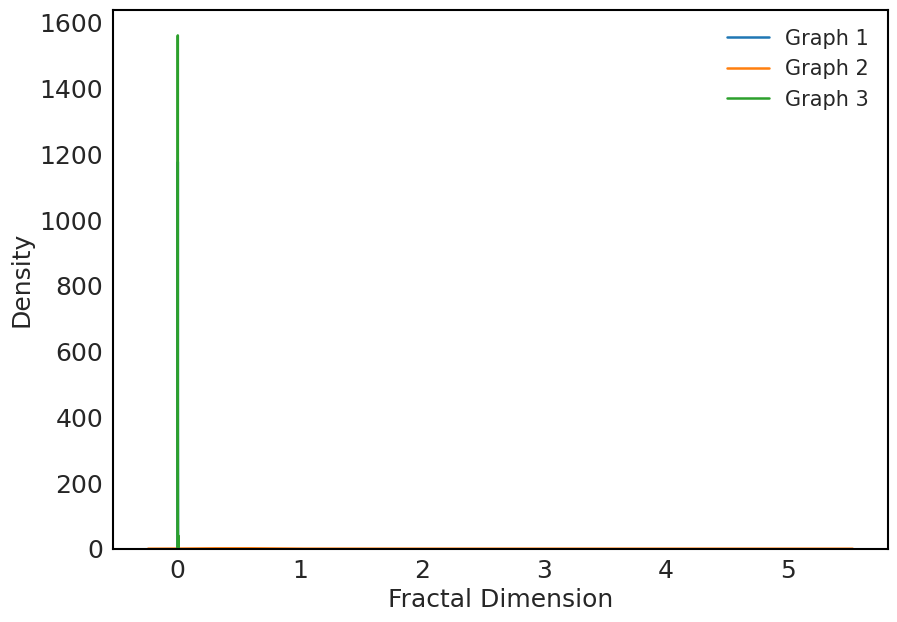

Average fractal dimension for Graph 1: 0.000552118554915476
Average fractal dimension for Graph 2: 0.5528517883803383
Average fractal dimension for Graph 3: 0.0003989853626276922
Average fractal dimension for Graph 4: 0.8191589458315638
Average fractal dimension for Graph 5: 0.3795032985457539


In [ ]:
nfd_centrality_list = []
avg_frac = []
for G in G_list:
    nfd_centrality = node_dimension(G, weight=True).values()
    nfd_centrality_list.append(list(nfd_centrality))
    avg_frac.append(np.mean(np.array(nfd_centrality_list[-1])))

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10, 7))
plt.grid(False)

for i, t in enumerate(["Graph 1", "Graph 2", "Graph 3"]):  # Adjust names as needed
    sns.kdeplot(list(nfd_centrality_list[i]), linewidth=1.8, label=t, color=f"C{i}")

plt.legend(frameon=False, loc='best', fontsize=15)
plt.xlabel('Fractal Dimension')
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.show()

for i, avg in enumerate(avg_frac):
    print(f"Average fractal dimension for Graph {i + 1}: {avg}")

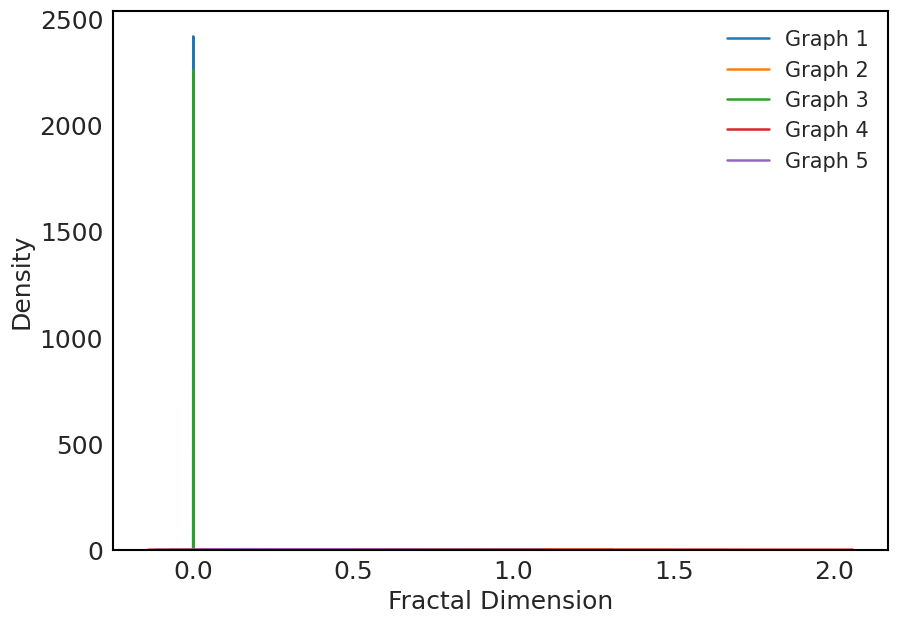

In [ ]:
def remove_outliers(data):
    """Remove outliers from a list using the IQR method."""
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return [x for x in data if lower_bound <= x <= upper_bound]

nfd_centrality_list_no_outliers = [remove_outliers(nfd_data) for nfd_data in nfd_centrality_list]

name = [f"Graph {i+1}" for i in range(len(nfd_centrality_list_no_outliers))]

plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10, 7))
plt.grid(False)

for i, t in enumerate(name):
    sns.kdeplot(list(nfd_centrality_list_no_outliers[i]), linewidth=1.8, label=t, color=f"C{i}")

plt.legend(frameon=False, loc='best', fontsize=15)
plt.xlabel('Fractal Dimension')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

plt.show()

### 3.3 Closeness centrality

In [ ]:
# Closeness centrality
closeness_centrality_list = []
avg_closeness = []
for G in tqdm(G_list):
    closeness_centrality = nx.closeness_centrality(G,distance='weight').values()
    closeness_centrality_list.append(list(closeness_centrality))
    avg_closeness.append(np.mean(np.array(closeness_centrality_list[-1])))

100%|██████████| 5/5 [00:10<00:00,  2.20s/it]


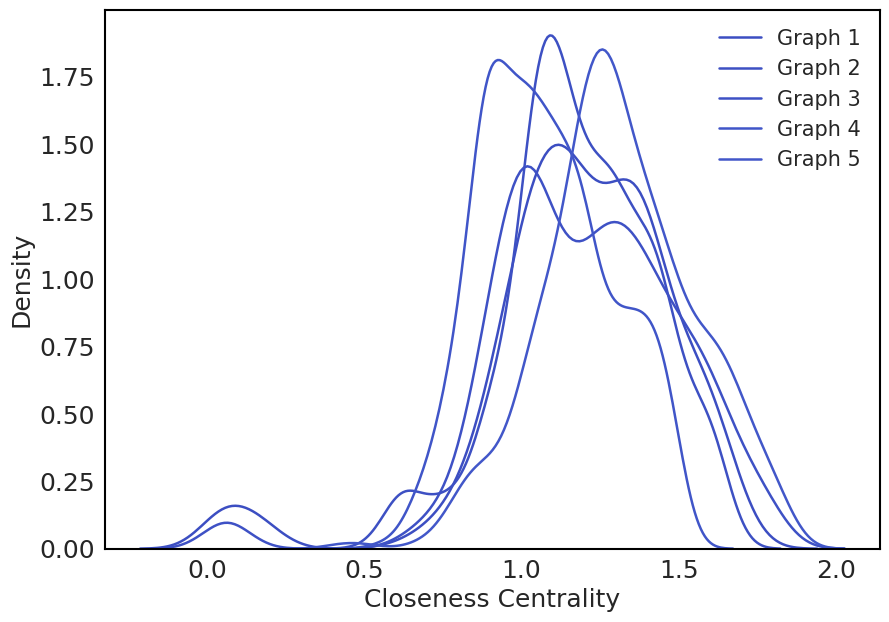

In [ ]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,7))
plt.grid(False)
for i,t in enumerate(name): #Peiyu:modify
    sns.kdeplot(list(closeness_centrality_list[i]),linewidth=1.8, label=t,color=colors[i])

plt.legend(frameon=False,loc='best',fontsize=15)
#plt.ylim([0,2.1])
plt.xlabel('Closeness Centrality')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# plt.savefig(root+'weighted_closeness_80kX.svg',bbox_inches = 'tight',dpi=600)
plt.show()

### 3.4 Degree centrality

In [ ]:
# Degree centrality
degree_centrality_list = []
avg_degree = []

for G in tqdm(G_list):
    degree_centrality = dict(G.degree(weight='weight')).values()
    degree_centrality_list.append(list(degree_centrality))
    avg_degree.append(np.mean(np.array(degree_centrality_list[-1])))


100%|██████████| 5/5 [00:00<00:00, 582.54it/s]


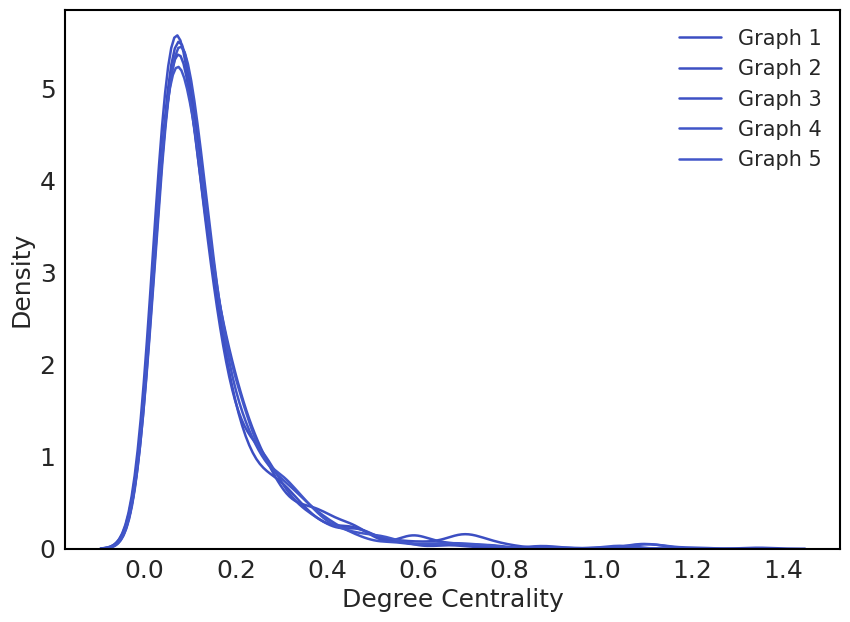

In [ ]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,7))
plt.grid(False)
# plt.title('Video 1: Reference')
for i,t in enumerate(name): #Peiyu:modify
    sns.kdeplot(list(degree_centrality_list[i]),linewidth=1.8, label=t,color=colors[i])

plt.legend(frameon=False,loc='best',fontsize=15)
#plt.ylim([0,2.1])
plt.xlabel('Degree Centrality')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# plt.savefig(root+'weighted_degree_80kX.svg',bbox_inches = 'tight',dpi=600)
plt.show()

### 3.5 Clustering coefficient

In [ ]:
# Clustering coefficient
cluster_coef_list = []

avg_clustering = []

for G in tqdm(G_list):
    cluster_coef = nx.clustering(G, weight='weight').values()
    cluster_coef_list.append(list(cluster_coef))
    avg_clustering.append(np.mean(np.array(cluster_coef_list[-1])))

100%|██████████| 5/5 [00:00<00:00, 45.52it/s]


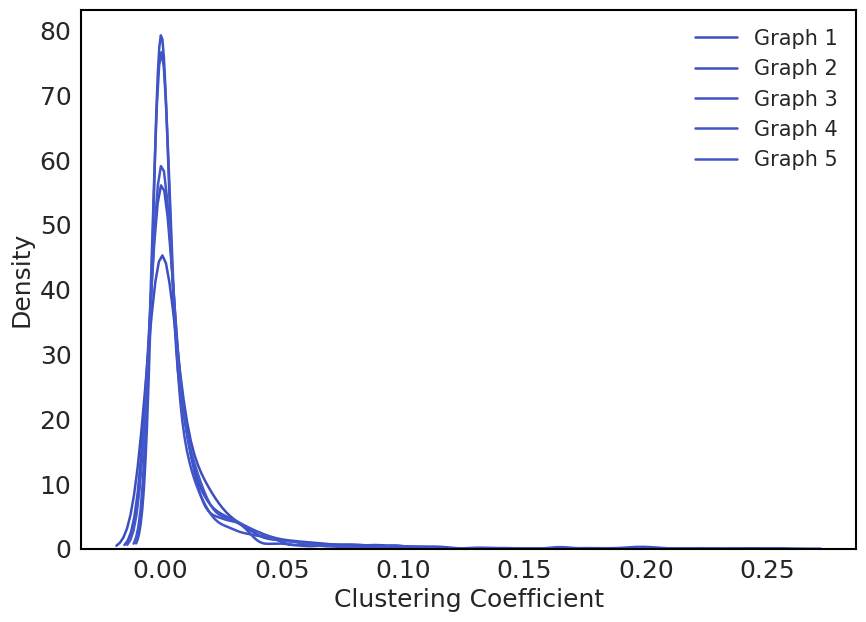

In [ ]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,7))
plt.grid(False)
# plt.title('Video 1: Reference')
for i,t in enumerate(name): #Peiyu:modify
    sns.kdeplot(list(cluster_coef_list[i]),linewidth=1.8, label=t,color=colors[i])

plt.legend(frameon=False,loc='best',fontsize=15)
#plt.ylim([0,2.1])
plt.xlabel('Clustering Coefficient')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# plt.savefig(root+'weighted_clustering_80kX.svg',bbox_inches = 'tight',dpi=600)
plt.show()

### 3.6 Betweeness

In [ ]:

# Calculate average betweenness centrality
betweenness_list = []
avg_betweenness_list = []
for G_nx in tqdm(G_list):
    G = nk.nxadapter.nx2nk(G_nx, weightAttr='weight')
    betweenness = nk.centrality.Betweenness(G, normalized=True).run()
    betweenness_list.append(betweenness.scores())
    avg_betweenness = sum(betweenness.scores()) / G.numberOfNodes()
    avg_betweenness_list.append(avg_betweenness)

100%|██████████| 5/5 [00:00<00:00, 11.12it/s]


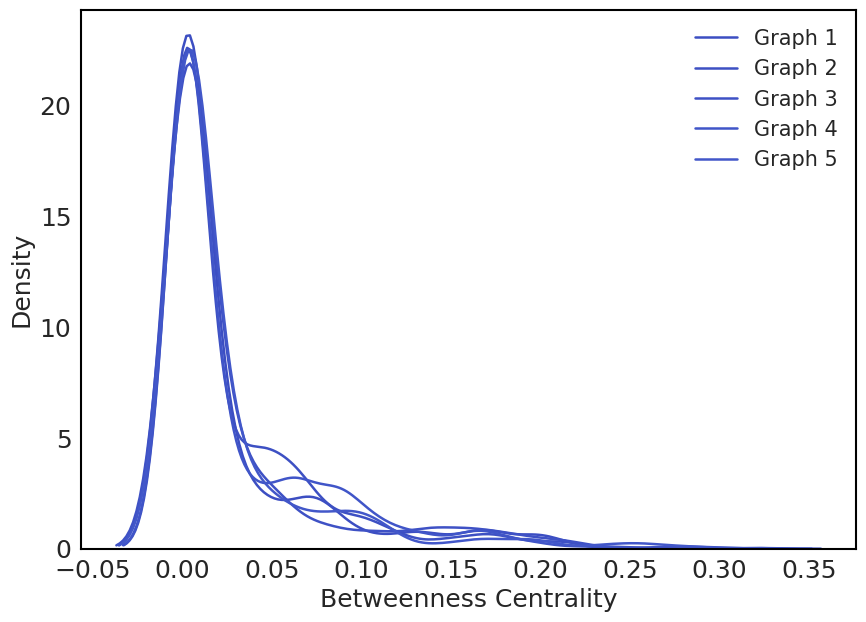

In [ ]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,7))
plt.grid(False)
# plt.title('Video 1: Reference')
for i,t in enumerate(name): #Peiyu:modify
    sns.kdeplot(list(betweenness_list[i]),linewidth=1.8, label=t,color=colors[i])

plt.legend(frameon=False,loc='best',fontsize=15)
#plt.ylim([0,2.1])
plt.xlabel('Betweenness Centrality')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# plt.savefig(root+'weighted_betweenness_80kX.svg',bbox_inches = 'tight',dpi=600)
plt.show()

### 3.7 Graph Ollivier-Ricci

In [ ]:
%pip install GraphRicciCurvature
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.4/835.4 kB 40.0 MB/s eta 0:00:00


In [ ]:
from GraphRicciCurvature.OllivierRicci import OllivierRicci

In [ ]:
avg_orcs = []
orc_list = []
for G in tqdm(G_list):
  avg_orc = []
  orc = OllivierRicci(nx.convert_node_labels_to_integers(G), alpha=0.5, verbose="ERROR")
  # 计算Ollivier-Ricci曲率
  orc.compute_ricci_curvature()
  G_orc = orc.G.copy()
  # 输出每条边的Ollivier-Ricci曲率
  for (u, v, d) in G_orc.edges(data=True):
    avg_orc.append(d['ricciCurvature'])
  orc_list.append(avg_orc)
  avg_orcs.append(np.mean(np.array(avg_orc)))

  0%|          | 0/5 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 5/5 [00:02<00:00,  1.78it/s]


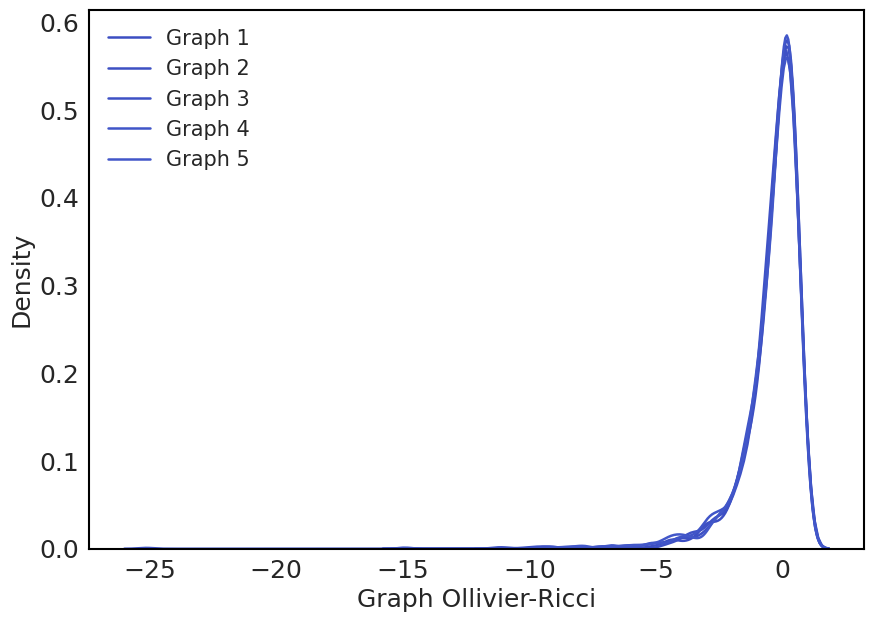

In [ ]:
plt.rcParams.update({'font.size': 18})
plt.figure(figsize=(10,7))
plt.grid(False)
# plt.title('Video 1: Reference')
for i,t in enumerate(name): #Peiyu:modify
    sns.kdeplot(list(orc_list[i]),linewidth=1.8, label=t,color=colors[i])

plt.legend(frameon=False,loc='best',fontsize=15)
#plt.ylim([0,2.1])
plt.xlabel('Graph Ollivier-Ricci')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# plt.savefig(root+'weighted_Ollivier-Ricci_80kX.svg',bbox_inches = 'tight',dpi=600)
plt.show()